In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

# ───────────────────────────────────────────────────────────────
# 1. Lettura del CSV
# ───────────────────────────────────────────────────────────────
df = pd.read_csv("merged_ils_mibs.csv")

# ───────────────────────────────────────────────────────────────
# 2. Split logico in blocchi ILS e MiBs (già allineati per instance)
# ───────────────────────────────────────────────────────────────
# --- BLOCCHI ILS (solo colonne usate nei grafici) ---
ils = df[[
    "instance",
    "ils_time_s",
    "delta_pct",
    "open_hotels_ils",
    "best_obj_ils",
    "ll_vars_ils",
    "ratio_cpu"
]].copy()

# --- BLOCCHI MiBs (solo colonne usate nei grafici) ---
mibs = df[[
    "instance",
    "cpu_time_s",
    "open_hotels_mibs",
    "best_obj_mibs"
]].copy()


# ───────────────────────────────────────────────────────────────
# 3. Colonna derivata ratio_cpu
# ───────────────────────────────────────────────────────────────
ils["ratio_cpu"] = ils["ils_time_s"] / mibs["cpu_time_s"]

# ───────────────────────────────────────────────────────────────
# 4. Etichette e assi
# ───────────────────────────────────────────────────────────────
labels = [f"I{i}" for i in ils["instance"]]
x      = np.arange(len(labels))
w      = 0.35



In [2]:
# ───────────────────────────────────────────────────────────────
# 5. Stile grafico
# ───────────────────────────────────────────────────────────────
PURPLE = "#7F77DD"
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
AMBER  = "#BA7517"
BLUE   = "#378ADD"
BG     = "#F8F8F6"
PANEL  = "#FFFFFF"
GRID   = "#E5E3DC"
TEXT   = "#2C2C2A"
MUTED  = "#888780"

plt.rcParams.update({
    "font.family":       "serif",
    "axes.facecolor":    PANEL,
    "figure.facecolor":  BG,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   MUTED,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "axes.grid":         True,
    "grid.color":        GRID,
    "grid.linewidth":    0.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    10,
    "axes.titleweight":  "normal",
    "axes.titlecolor":   TEXT,
    "axes.labelsize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
})



✓ Grafico salvato come ils_mibs_comparison.png


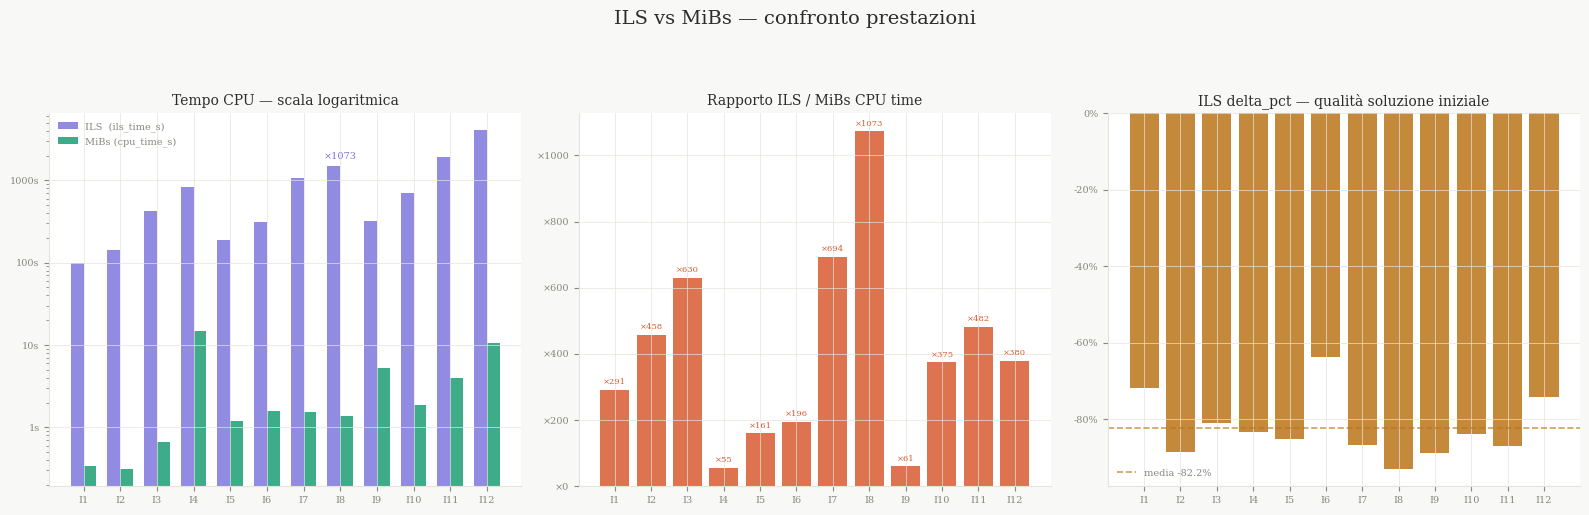

In [3]:
# ───────────────────────────────────────────────────────────────
# 6. Figura — 3 grafici in linea
# ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("ILS vs MiBs — confronto prestazioni", fontsize=14,
             color=TEXT, fontweight="normal", y=1.02)
fig.patch.set_facecolor(BG)

# ───────────────────────────────────────────────────────────────
#  GRAFICO 1 — Tempo CPU (log)
# ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.bar(x - w/2, ils["ils_time_s"],  w, label="ILS  (ils_time_s)",  color=PURPLE, alpha=0.85)
ax.bar(x + w/2, mibs["cpu_time_s"], w, label="MiBs (cpu_time_s)", color=TEAL,   alpha=0.85)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}s"))
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("Tempo CPU — scala logaritmica")
ax.legend(fontsize=7, frameon=False, labelcolor=MUTED)

worst = int(ils["ratio_cpu"].argmax())
ax.annotate(f"×{ils['ratio_cpu'].iloc[worst]:.0f}",
            xy=(x[worst], ils["ils_time_s"].iloc[worst]),
            xytext=(0, 5), textcoords="offset points",
            ha="center", fontsize=7, color=PURPLE)

# ───────────────────────────────────────────────────────────────
#  GRAFICO 2 — Rapporto ILS/MiBs
# ───────────────────────────────────────────────────────────────
ax = axes[1]
ratio = ils["ratio_cpu"].tolist()
bars  = ax.bar(x, ratio, color=CORAL, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("Rapporto ILS / MiBs CPU time")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"×{v:.0f}"))
for bar, r in zip(bars, ratio):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(ratio)*0.01,
            f"×{r:.0f}", ha="center", va="bottom", fontsize=6, color=CORAL)

# ───────────────────────────────────────────────────────────────
#  GRAFICO 3 — delta_pct
# ───────────────────────────────────────────────────────────────
ax = axes[2]
dp = ils["delta_pct"].tolist()
ax.bar(x, dp, color=AMBER, alpha=0.85)
ax.axhline(np.mean(dp), color=AMBER, linewidth=1.2, linestyle="--", alpha=0.7,
           label=f"media {np.mean(dp):.1f}%")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("ILS delta_pct — qualità soluzione iniziale")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(fontsize=7, frameon=False, labelcolor=MUTED)

# ───────────────────────────────────────────────────────────────
#  Layout finale
# ───────────────────────────────────────────────────────────────
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("ils_mibs_comparison.png", dpi=150, bbox_inches="tight")
print("✓ Grafico salvato come ils_mibs_comparison.png")
plt.show()


**GRAFICO 1 — Tempo CPU (scala log)**

il tempo interno di ILS (ils_time_s) è di ordini di grandezza  superiore al cpu_time_s di MiBs. La scala logaritmica rende la presentazione dei dati più leggibile.

**GRAFICO 2 — Rapporto ILS / MiBs CPU**
il rapporto varia da ×55 (I4, istanza difficile per entrambi) a ×1073 (I8). Mostra che ILS è sempre più costoso in CPU; il vantaggio    euristico non emerge su queste istanze perché MiBs non genera tagli.

**GRAFICO 3 -ILS delta_pct**
Il delta_pct misura quanto la soluzione iniziale di ILS sia lontana dal best_obj finale. Valori sempre molto negativi (media ~-82%) indicano che ILS parte da soluzioni scadenti e deve fare molta local search, questo spiega l'alto costo CPU.    

✓ Grafico salvato come ils_mibs_hotels_bestobj.png


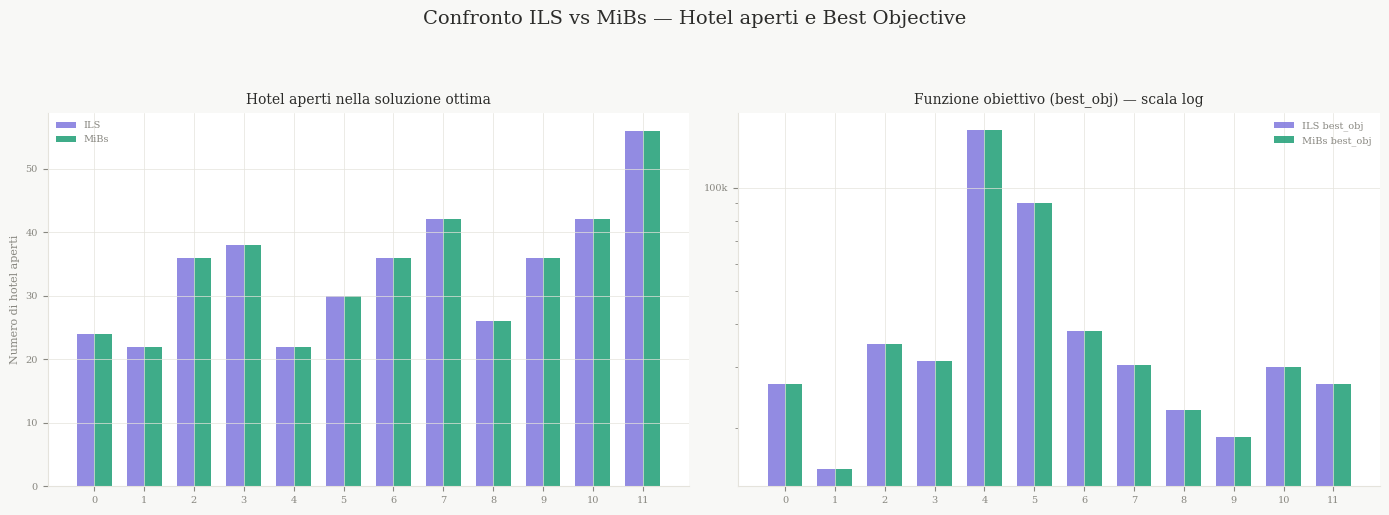

In [4]:
# ───────────────────────────────────────────────────────────────
# Figura con due grafici: hotel aperti + best_obj
# ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confronto ILS vs MiBs — Hotel aperti e Best Objective",
             fontsize=14, color=TEXT, fontweight="normal", y=1.02)
fig.patch.set_facecolor(BG)

# ================================================================
#  GRAFICO A — Hotel aperti
# ================================================================
ax = axes[0]

ax.bar(x - w/2, ils["open_hotels_ils"],  w,
       label="ILS",  color=PURPLE, alpha=0.85)

ax.bar(x + w/2, mibs["open_hotels_mibs"], w,
       label="MiBs", color=TEAL,   alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(x)   # ← numeri 1,2,3,...

ax.set_title("Hotel aperti nella soluzione ottima")
ax.set_ylabel("Numero di hotel aperti")
ax.legend(fontsize=7, frameon=False, labelcolor=MUTED)

# ================================================================
#  GRAFICO B — Best Objective (log scale)
# ================================================================
ax = axes[1]

ax.bar(x - w/2, ils["best_obj_ils"],  w,
       label="ILS best_obj",  color=PURPLE, alpha=0.85)

ax.bar(x + w/2, mibs["best_obj_mibs"], w,
       label="MiBs best_obj", color=TEAL,   alpha=0.85)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"{v/1e6:.1f}M" if v >= 1e6 else
                 f"{v/1e3:.0f}k" if v >= 1e3 else f"{v:.0f}"
))

ax.set_xticks(x)
ax.set_xticklabels(x)   # ← numeri 1,2,3,...

ax.set_title("Funzione obiettivo (best_obj) — scala log")
ax.legend(fontsize=7, frameon=False, labelcolor=MUTED)

# ================================================================
# Layout finale
# ================================================================
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("ils_mibs_hotels_bestobj.png", dpi=150, bbox_inches="tight")
print("✓ Grafico salvato come ils_mibs_hotels_bestobj.png")
plt.show()


 **GRAFICO 5 — Hotel aperti per istanza**
  ILS e MiBs restituiscono lo stesso numero di hotel aperti, confermando che entrambi trovano la stessa soluzione ottima. *Il numero di hotel cresce con la dimensione del problema, ma non linearmente, è dipendente dalla struttura bilivello (leader/follower trade-off)*

 **GRAFICO 6 — Funzione obiettivo per istanza **
Le scale dei best_obj sono molto diverse tra le istanze (da ~15k a ~147k), sottolineando la dipendenda della funzione dal dataset.
 ILS e MiBs trovano esattamente gli stessi valori (opt_gap = 0%) la qualità della soluzione finale è identica; la differenza è nel costo computazionale molto più alto per l'algoritmo ILS.

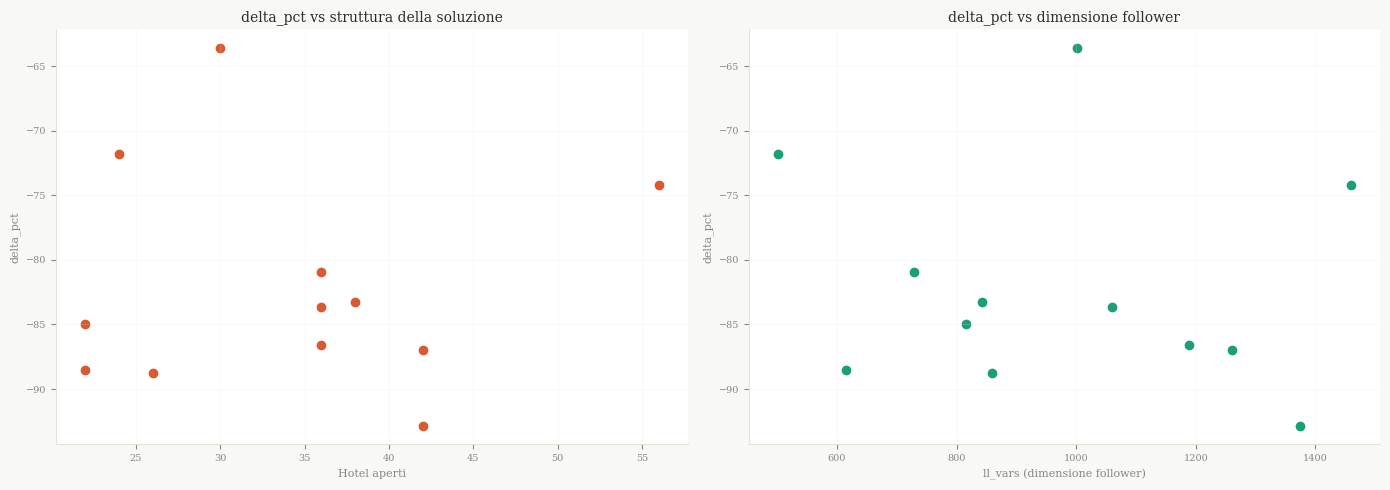

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ───────────────────────────────────────────────
# GRAFICO 1 — delta_pct vs hotel aperti
# ───────────────────────────────────────────────
ax = axes[0]
ax.scatter(df["open_hotels_ils"], df["delta_pct"], color="#D85A30")
ax.set_xlabel("Hotel aperti")
ax.set_ylabel("delta_pct")
ax.set_title("delta_pct vs struttura della soluzione")
ax.grid(True, alpha=0.3)

# ───────────────────────────────────────────────
# GRAFICO 2 — delta_pct vs dimensione follower
# ───────────────────────────────────────────────
ax = axes[1]
ax.scatter(df["ll_vars_ils"], df["delta_pct"], color="#1D9E75")
ax.set_xlabel("ll_vars (dimensione follower)")
ax.set_ylabel("delta_pct")
ax.set_title("delta_pct vs dimensione follower")
ax.grid(True, alpha=0.3)

# Layout finale
plt.tight_layout()
plt.show()


**Grafico 1 — delta_pct vs Hotel aperti**
Dallo scatter emerge che il delta_pct è sistematicamente molto negativo (da −63% a −93%) indipendentemente dal numero di hotel aperti. Non si vede una tendenza lineare chiara: sia istanze con 22 hotel che con 56 hotel mostrano delta_pct simili. Questo suggerisce che la struttura della soluzione (quanti hotel aprire) non è la causa principale dell'errore dell'ILS.

**Grafico 2 — delta_pct vs Dimensione follower (ll_vars)**

Il delta_pct è sparso senza una tendenza monotona evidente. Le istanze con follower più grande (ll_vars > 1200) non sembrano necessariamente peggiori in termini di delta_pct rispetto a quelle piccole: la dimensione del problema lower-level non correla direttamente con la qualità della soluzione ILS, almeno sul range di dati disponibili.